In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from Bio import SeqIO
from io import StringIO

In [20]:
raw_file = "8temp.tsv"
dataset = "protein_dataset.tsv"

df = pd.read_csv(raw_file, sep="\t")
total_rows = len(df)

df_no_duplicates = df.drop_duplicates(keep="last")
rows_after_dedup = len(df_no_duplicates)
duplicates_removed = total_rows - rows_after_dedup

df_no_duplicates.to_csv(dataset, sep="\t", index=False)

print(f"Total rows before deduplication: {total_rows}")
print(f"Total rows after deduplication: {rows_after_dedup}")
print(f"Number of duplicate rows removed: {duplicates_removed}")

Total rows before deduplication: 32280
Total rows after deduplication: 31108
Number of duplicate rows removed: 1172


In [22]:
def get_sequence_from_uniprot(uniprot_id, max_retries=5):
    """Function to retrieve protein sequences from UniProt API"""
    url = f"https://rest.uniprot.org/uniprotkb/{uniprot_id}.fasta"

    session = requests.Session()
    retry_strategy = Retry(
        total=max_retries,
        backoff_factor=1,
        status_forcelist=[429, 500, 502, 503, 504],
        allowed_methods=["GET"],
    )
    adapter = HTTPAdapter(max_retries=retry_strategy)
    session.mount("https://", adapter)

    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) Python/3.13 Protein-Sequence-Retrieval"
    }

    try:
        response = session.get(url, headers=headers, timeout=30)
        if response.status_code == 200:
            fasta = StringIO(response.text)
            for record in SeqIO.parse(fasta, "fasta"):
                return str(record.seq)
            
    except Exception as e:
        print(f"Error retrieving sequence for {uniprot_id}: {str(e)}")

    return None


def load_local_uniprot_database(fasta_file="uniprot_sprot.fasta"):
    """Function to load UniProt database from local FASTA file"""
    print("Loading local UniProt database...")
    uniprot_dict = {}
    for record in SeqIO.parse(fasta_file, "fasta"):
        uniprot_id = record.id.split("|")[1] if "|" in record.id else record.id
        uniprot_dict[uniprot_id] = str(record.seq)
    print(f"Loaded {len(uniprot_dict)} sequences from local database")
    return uniprot_dict


def process_uniprot_ids(input_file, output_file, use_api=True):
    """Process UniProt IDs from input file, retrieve sequences"""
    try:
        data = pd.read_csv(input_file, sep="\t")
        unique_uniprot_ids = data["UniProt_ID"].unique()
        
        # Local database
        uniprot_dict = load_local_uniprot_database()
        found_sequences = {}
        
        for uniprot_id in unique_uniprot_ids:
            if uniprot_id in uniprot_dict:
                found_sequences[uniprot_id] = uniprot_dict[uniprot_id]
        
        api_found = 0
        if use_api:
            remaining_ids = [id for id in unique_uniprot_ids if id not in found_sequences]
            
            for uniprot_id in remaining_ids:
                seq = get_sequence_from_uniprot(uniprot_id)
                if seq:
                    found_sequences[uniprot_id] = seq
                    api_found += 1
            
            print(f"Found {api_found} additional sequences via API")
        
        data["Protein_Sequence"] = data["UniProt_ID"].map(found_sequences)
        data.to_csv(output_file, sep="\t", index=False)

        print(f"Processed {len(found_sequences)} unique UniProt IDs")
        print(
            f"Success rate: {len(found_sequences)}/{len(unique_uniprot_ids)} ({len(found_sequences)/len(unique_uniprot_ids)*100:.1f}%)"
        )

    except Exception as e:
        print(f"An error occurred during processing: {str(e)}")

process_uniprot_ids(raw_file, dataset, use_api=True)


Loading local UniProt database...
Loaded 572970 sequences from local database
Found 100 additional sequences via API
Processed 923 unique UniProt IDs
Success rate: 923/942 (98.0%)


In [23]:
df = pd.read_csv(dataset, sep="\t")
total_rows = len(df)

df_filtered = df.dropna(subset=["Protein_Sequence"])
df_filtered = df_filtered[df_filtered["Protein_Sequence"].str.strip() != ""]

filtered_rows = len(df_filtered)
removed_rows = total_rows - filtered_rows

df_filtered.to_csv(dataset, sep="\t", index=False)

print(f"Total rows in original file: {total_rows}")
print(f"Rows removed (no sequence): {removed_rows}")
print(f"Rows remaining: {filtered_rows}")
print(f"Filtered data saved to {dataset}")

Total rows in original file: 32280
Rows removed (no sequence): 2766
Rows remaining: 29514
Filtered data saved to protein_dataset.tsv


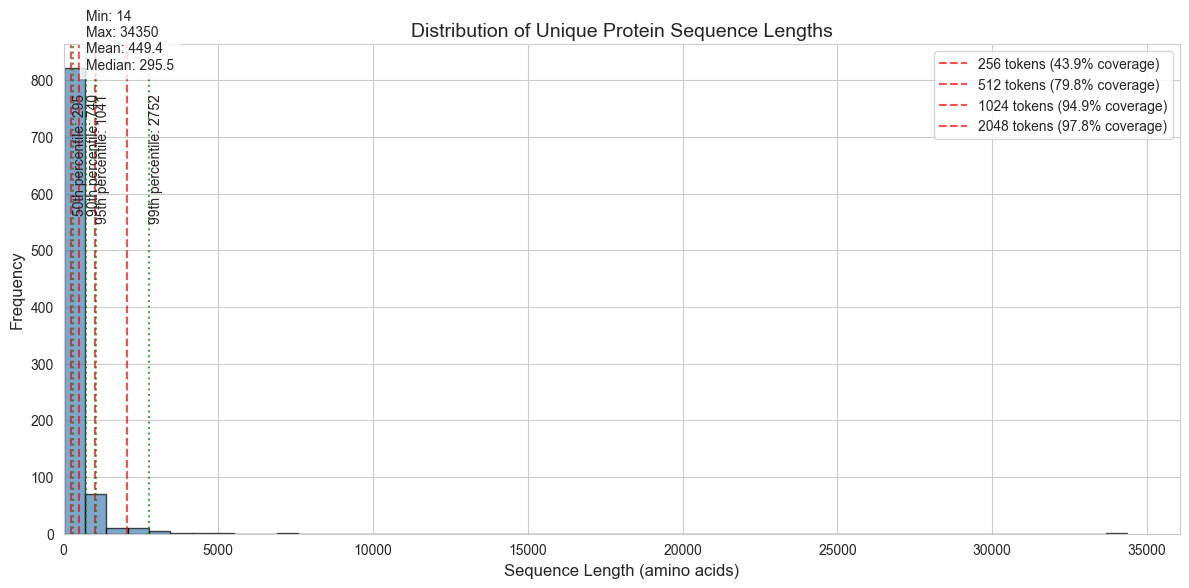

In [24]:
dataset = "protein_dataset.tsv"

def plot_sequence_length_distribution(file_path):
    sns.set_style("whitegrid")
    plt.figure(figsize=(12, 6))

    df = pd.read_csv(file_path, sep="\t")
    unique_sequences = df['Protein_Sequence'].unique()
    sequence_lengths = [len(seq) for seq in unique_sequences]

    plt.hist(sequence_lengths, bins=50, alpha=0.7, color="steelblue", edgecolor="black")

    common_lengths = [256, 512, 1024, 2048]
    for length in common_lengths:
        plt.axvline(
            x=length,
            color="red",
            linestyle="--",
            alpha=0.7,
            label=f"{length} tokens" if length == common_lengths[0] else f"{length}",
        )
        
    percentiles = [50, 90, 95, 99]
    percentile_values = np.percentile(sequence_lengths, percentiles)

    for p, val in zip(percentiles, percentile_values):
        plt.axvline(x=val, color="green", linestyle=":", alpha=0.7)
        plt.text(
            val + 10,
            plt.gca().get_ylim()[1] * 0.9,
            f"{p}th percentile: {int(val)}",
            rotation=90,
            verticalalignment="top",
        )

    coverage = {}
    for length in common_lengths:
        coverage[length] = (np.array(sequence_lengths) <= length).mean() * 100

    coverage_labels = [
        f"{length} tokens ({coverage[length]:.1f}% coverage)" for length in common_lengths
    ]
    plt.legend(coverage_labels, loc="upper right")

    plt.xlabel("Sequence Length (amino acids)", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.title("Distribution of Unique Protein Sequence Lengths", fontsize=14)

    stats_text = (
        f"Min: {min(sequence_lengths)}\n"
        f"Max: {max(sequence_lengths)}\n"
        f"Mean: {np.mean(sequence_lengths):.1f}\n"
        f"Median: {np.median(sequence_lengths)}"
    )
    plt.text(
        0.02,
        0.95,
        stats_text,
        transform=plt.gca().transAxes,
        bbox=dict(facecolor="white", alpha=0.8),
    )

    plt.xlim(left=0)
    plt.tight_layout()
    plt.show()

plot_sequence_length_distribution(dataset)

Total sequences: 29515
Sequences within length limit (30000): 29497
Sequences removed: 18 (0.06%)
Filtered data saved to: protein_dataset.tsv

Unique sequences before filtering: 923
Unique sequences after filtering: 922
Unique sequences removed: 1 (0.11%)


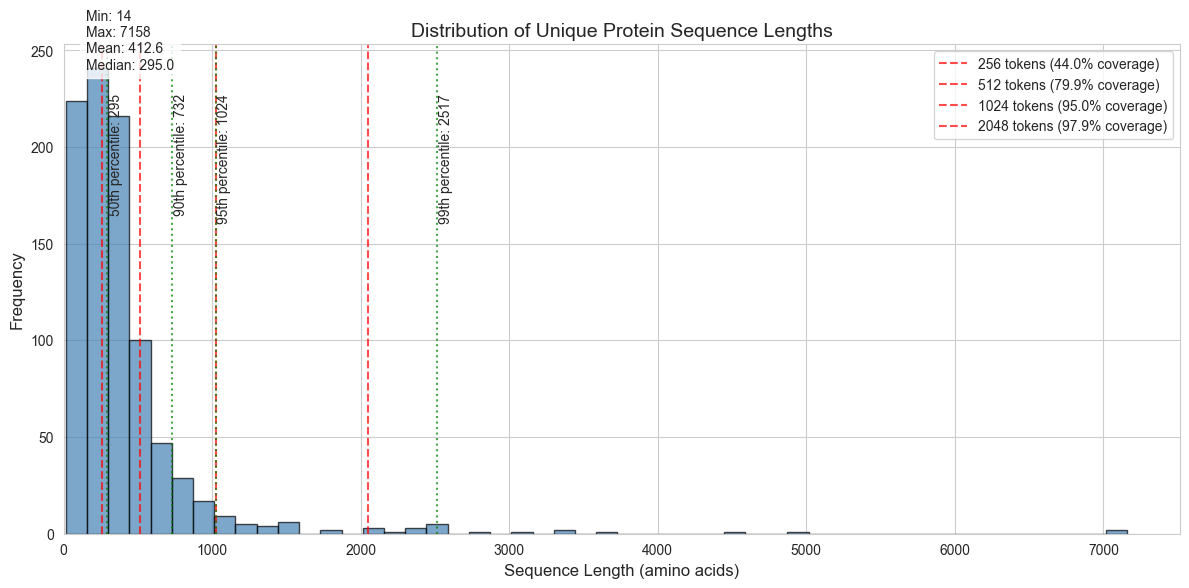

In [25]:
max_length = 30000

df = pd.read_csv(dataset, sep='\t', header=None)

sequence_col = df.iloc[:, -1]
sequence_lengths = sequence_col.str.len()
filtered_df = df[sequence_lengths <= max_length]

filtered_df.to_csv(dataset, sep='\t', header=False, index=False)

total_sequences = len(df)
filtered_sequences = len(filtered_df)
removed_sequences = total_sequences - filtered_sequences

unique_sequences_before = sequence_col.nunique()
unique_sequences_after = filtered_df.iloc[:, -1].nunique()
unique_sequences_removed = unique_sequences_before - unique_sequences_after

print(f"Total sequences: {total_sequences}")
print(f"Sequences within length limit ({max_length}): {filtered_sequences}")
print(f"Sequences removed: {removed_sequences} ({removed_sequences/total_sequences*100:.2f}%)")
print(f"Filtered data saved to: {dataset}")

print(f"\nUnique sequences before filtering: {unique_sequences_before}")
print(f"Unique sequences after filtering: {unique_sequences_after}")
print(f"Unique sequences removed: {unique_sequences_removed} ({unique_sequences_removed/unique_sequences_before*100:.2f}%)")

plot_sequence_length_distribution(dataset)

In [26]:
df = pd.read_csv(dataset, sep='\t')

found = False
for idx, row in df.iterrows():
    if row['SEC_STR'] == '-4.38':
        df.at[idx, 'SEC_STR'] = "Coil"
        found = True

if found:
    df.to_csv(dataset, sep='\t', index=False)
    print("File saved with the corrected SEC_STR value.")
else:
    print("No entry found with SEC_STR value = -4.38")

File saved with the corrected SEC_STR value.


In [27]:
COIL = 0
HELIX = 1
SHEET = 2
TURN = 3


def encode_secondary_structure(structure_text):
    """
    Encode secondary structure information as a count vector.
    Format: [coil_count, helix_count, sheet_count, turn_count]
    """
    if not structure_text or structure_text == "-":
        return [0, 0, 0, 0]

    counts = [0, 0, 0, 0]
    structures = [s.strip() for s in structure_text.split(",")]

    for structure in structures:
        if "Coil" in structure:
            counts[COIL] += 1
        elif "Helix" in structure:
            counts[HELIX] += 1
        elif "Sheet" in structure:
            counts[SHEET] += 1
        elif "Turn" in structure:
            counts[TURN] += 1

    return counts


df = pd.read_csv(dataset, sep="\t")
df["SEC_STR_ENCODED"] = df["SEC_STR"].apply(encode_secondary_structure)
df.to_csv(dataset, sep="\t", index=False)

print("\nSecondary Structure Types and Their Encodings:")
print("-" * 50)
print(f"{'Secondary Structure':<25} {'Count-Based Encoding'}")
print("-" * 50)

examples = [
    "Coil",
    "Helix",
    "Sheet",
    "Turn",
    "Helix, Sheet",
    "Helix, Turn, Turn",
    "-",
]

for example in examples:
    encoding = encode_secondary_structure(example)
    print(f"{example:<25} {encoding}")


Secondary Structure Types and Their Encodings:
--------------------------------------------------
Secondary Structure       Count-Based Encoding
--------------------------------------------------
Coil                      [1, 0, 0, 0]
Helix                     [0, 1, 0, 0]
Sheet                     [0, 0, 1, 0]
Turn                      [0, 0, 0, 1]
Coil, Coil                [2, 0, 0, 0]
Helix, Sheet              [0, 1, 1, 0]
Helix, Turn, Turn         [0, 1, 0, 2]
-                         [0, 0, 0, 0]


Embedding...

In [28]:
from transformers import AutoTokenizer, AutoModel
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
from tqdm import tqdm

Sequence length:  65
Embedding shape: torch.Size([1, 320])


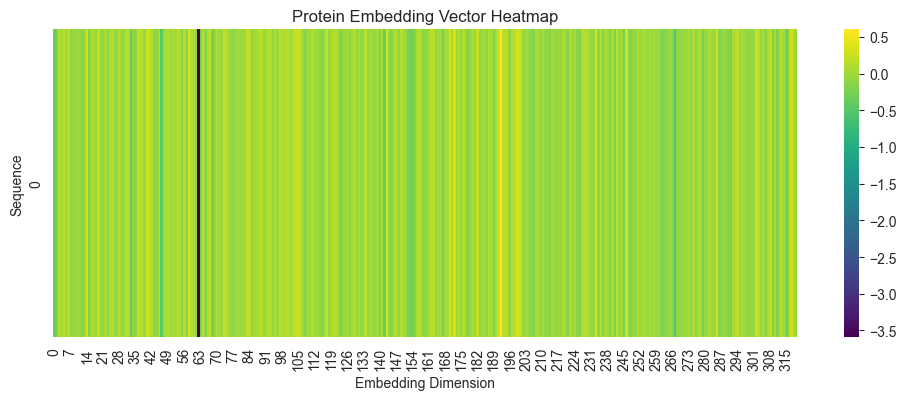

In [29]:
tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t6_8M_UR50D")
model = AutoModel.from_pretrained("facebook/esm2_t6_8M_UR50D", add_pooling_layer=False)

sequence = "MKTVRQERLKSIVRILERSKEPVSGAQLAEELSVSRQVIVQDIAYLRSLGYNIVATPRGYVLAGG"
print("Sequence length: ", len(sequence))

inputs = tokenizer(sequence, return_tensors="pt")
with torch.no_grad():
    outputs = model(**inputs)

embeddings = outputs.last_hidden_state.mean(dim=1)

print(f"Embedding shape: {embeddings.shape}")

plt.figure(figsize=(12, 4))
sns.heatmap(embeddings.numpy(), cmap="viridis")
plt.title("Protein Embedding Vector Heatmap")
plt.xlabel("Embedding Dimension")
plt.ylabel("Sequence")
plt.show()

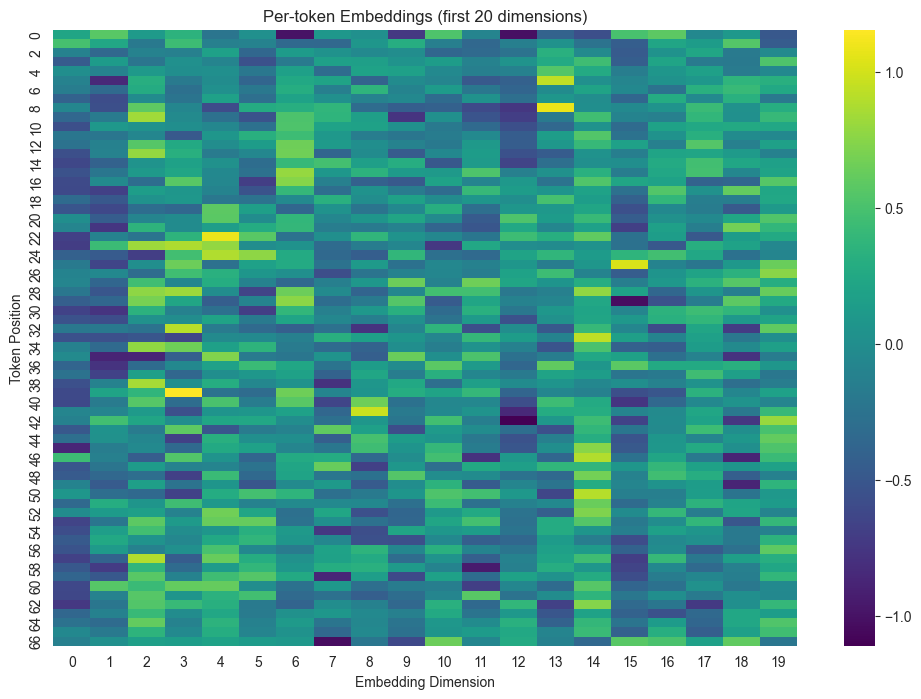

In [30]:
token_embeddings = outputs.last_hidden_state[0]

plt.figure(figsize=(12, 8))
sns.heatmap(token_embeddings.numpy()[:, :20], cmap="viridis")
plt.title("Per-token Embeddings (first 20 dimensions)")
plt.xlabel("Embedding Dimension")
plt.ylabel("Token Position")
plt.show()

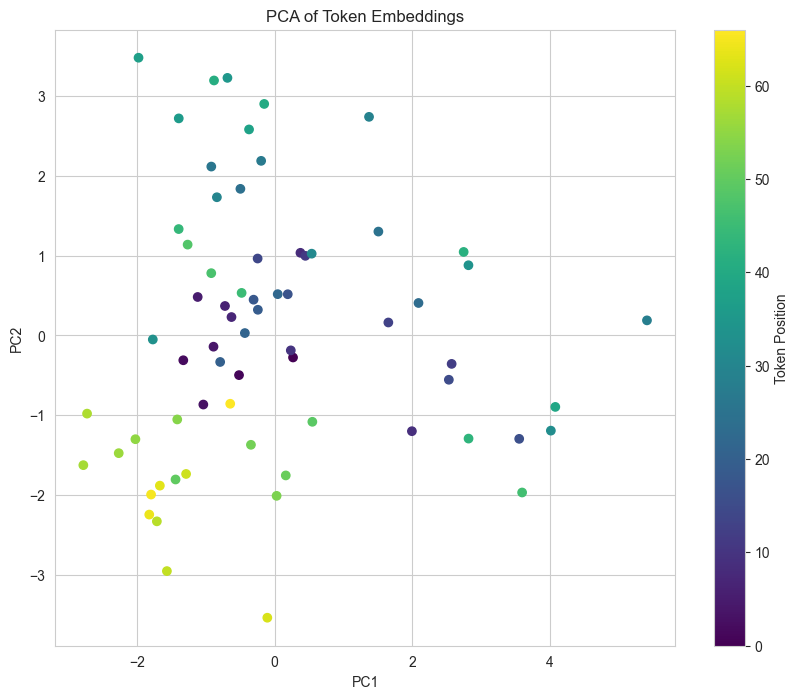

In [15]:
pca = PCA(n_components=2)
token_embeddings_2d = pca.fit_transform(token_embeddings.numpy())

plt.figure(figsize=(10, 8))
plt.scatter(
    token_embeddings_2d[:, 0],
    token_embeddings_2d[:, 1],
    c=np.arange(token_embeddings_2d.shape[0]),
    cmap="viridis",
)
plt.colorbar(label="Token Position")
plt.title("PCA of Token Embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [16]:
# Unembedding the sequence
print("\nUnembedding the sequence:")
tokens = tokenizer.convert_ids_to_tokens(inputs.input_ids[0])
amino_acids = [token.replace("<", "").replace(">", "") for token in tokens]
amino_acids = [aa for aa in amino_acids if aa not in ["cls", "pad", "eos", "mask"]]
unembedded_sequence = "".join(amino_acids)
print("Original sequence:", sequence)
print("Unembedded sequence:", unembedded_sequence)
print("Equal:", sequence == unembedded_sequence)


Unembedding the sequence:
Original sequence: MKTVRQERLKSIVRILERSKEPVSGAQLAEELSVSRQVIVQDIAYLRSLGYNIVATPRGYVLAGG
Unembedded sequence: MKTVRQERLKSIVRILERSKEPVSGAQLAEELSVSRQVIVQDIAYLRSLGYNIVATPRGYVLAGG
Equal: True


In [31]:
embeddings_file = "sequence_embeddings.csv"

df = pd.read_csv(dataset, sep="\t")
print(f"Number of rows before removing duplicates: {len(df)}")

df = df[["UniProt_ID", "Protein_Sequence"]]
df = df.drop_duplicates(subset=["UniProt_ID"], keep="first")
print(f"Number of rows after removing duplicates: {len(df)}")

df.to_csv(embeddings_file, index=False)
print(f"Unique protein data saved to {embeddings_file}")

Number of rows before removing duplicates: 29496
Number of rows after removing duplicates: 922
Unique protein data saved to sequence_embeddings.csv


In [32]:
print("Loading protein language model and tokenizer...")
model_name = "facebook/esm2_t6_8M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Using device: {device}")

print("Loading dataset...")
df = pd.read_csv(embeddings_file)
print(f"Dataset loaded with {len(df)} rows containing protein sequences")


def generate_embedding(sequence, normalize=True):
    if not isinstance(sequence, str) or len(sequence) == 0:
        return None

    inputs = tokenizer(sequence, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    embedding = outputs.last_hidden_state[:, 0, :].cpu().numpy()[0]
    
    # L2 normalization (unit vector)
    if normalize:
        norm = np.linalg.norm(embedding)
        if norm > 0:
            embedding = embedding / norm
            
    return embedding


print("Generating embeddings for all proteins...")
embeddings = []
uniprot_ids = []
sequences = []
embedding_strings = []

for idx, row in tqdm(df.iterrows(), total=len(df)):
    uniprot_id = row["UniProt_ID"]
    sequence = row["Protein_Sequence"]

    embedding = generate_embedding(sequence)

    if embedding is not None:
        embeddings.append(embedding)
        uniprot_ids.append(uniprot_id)
        sequences.append(sequence)
        embedding_str = str(embedding)
        embedding_strings.append(embedding_str)

results_df = pd.DataFrame(
    {
        "UniProt_ID": uniprot_ids,
        "Protein_Sequence": sequences,
        "Embedding": embedding_strings,
    }
)

results_df.to_csv(embeddings_file, index=False)

print(f"Completed! Generated embeddings for {len(embeddings)} proteins")
print(f"Embedding dimension: {len(embedding) if embeddings else 0}")
print(f"Results saved to {embeddings_file}")

Loading protein language model and tokenizer...


Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using device: cpu
Loading dataset...
Dataset loaded with 922 rows containing protein sequences
Generating embeddings for all proteins...


100%|██████████| 922/922 [03:24<00:00,  4.50it/s]

Completed! Generated embeddings for 922 proteins
Embedding dimension: 320
Results saved to sequence_embeddings.csv
